# Nahfeld und Fernfeld — das Rechenbuch zum Wake-Modell

> Im Stil von »Das Gelbe Rechenbuch« (P. Furlan): **Rezepte** statt
> Beweise, zu jedem Rezept ein **Beispiel** und eine **Probe**.
> Herleitungen und Fehleranalyse stehen in
> `explain_nearfield_farfield_model.ipynb`.

**Aufgabe.** Die induzierte Spannung ist die Faltung der Liniendichte
$\lambda$ mit der Wake-Funktion $W$ einer Punktladung:

$$V(t) \;=\; \int_{-\infty}^{\infty} W(t - t')\,\lambda(t')\,\mathrm{d}t' .$$

Der Tracking-Code kennt aber nur ein Histogramm: Ladungen $q_j$ in Bins der
Breite $\Delta t$ mit den Mitten $t_j$. Gesucht ist eine Zahl $V_i$ pro Bin —
mit festem Aufwand pro Bin und Pol, und ohne den bekannten Aliasing-Fehler
bei Resonatoren kleiner Güte.

**Ergebnis vorweg** (`MultiPoleSparseSolve`): Pro Pol der Impedanz besteht
$V_i$ aus zwei Teilen:

* **Fernfeld** — alle Ladungen, die mindestens zwei Bins zurückliegen. Sie
  stecken zusammen in einer einzigen komplexen Zahl $S$, die pro Bin einmal
  multipliziert und um eine Ladung ergänzt wird.
* **Nahfeld** — die Ladungen im vorigen, im eigenen und im nächsten Bin,
  jede mit einem vorab berechneten Gewicht.

**Bezeichnungen.**

| Symbol | Bedeutung | Einheit |
|---|---|---|
| $\lambda(t)$ | Liniendichte des Strahls | C/s |
| $W(\tau)$ | Wake-Funktion einer Punktladung | V/C |
| $Z(f)$ | Impedanz | $\Omega$ |
| $R_s,\ f_r,\ Q$ | Shuntimpedanz, Resonanzfrequenz, Güte | $\Omega$, Hz, 1 |
| $\alpha,\ \bar\omega$ | Dämpfungsrate, gedämpfte Kreisfrequenz | 1/s, rad/s |
| $p,\ \rho$ | Pol, Residuum | 1/s, V/C |
| $\Delta t$ | Binbreite des Profils | s |
| $q_j,\ t_j$ | Ladung und Mitte von Bin $j$ | C, s |
| $\overline W$ | über die Bins gemittelte Wake | V/C |
| $B_2$ | quadratischer B-Spline (Faltung dreier Rechtecke) | 1/s |
| $V_i$ | induzierte Spannung in Bin $i$ | V |
| $S$ | laufende Summe der Rekursion (eine pro Pol) | C |
| $m$ | Abstand in Bins | 1 |
| $k$ | Anzahl der Rechteck-Mittelungen | 1 |
| $\ell$ | Nummer des Alias-Anteils | 1 |

**Konventionen.** $Z(f) = \int W(\tau)\,e^{-2\pi i f\tau}\,\mathrm d\tau$,
$s = i\omega = 2\pi i f$, $Q > \tfrac12$, SI-Einheiten. Das negative
Vorzeichen, das die Solver voranstellen (damit eine resistive Impedanz
bremst), ist hier weggelassen.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import erf

plt.rcParams["figure.figsize"] = (9.0, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Resonator → Pol und Residuum

Die Impedanz eines RLC-Parallelschwingkreises,

$$Z(f) \;=\; \frac{R_s}{1 + iQ\left(\frac{f}{f_r} - \frac{f_r}{f}\right)}
\;=\; \left.\frac{\frac{\omega_r}{Q} R_s\, s}
{s^2 + \frac{\omega_r}{Q}\, s + \omega_r^2}\right|_{s = 2\pi i f},$$

zerfällt per Partialbruchzerlegung in zwei konjugierte Pole,
$Z(s) = \frac{\rho}{s-p} + \frac{\rho^*}{s-p^*}$. Jeder Pol ergibt im
Zeitbereich eine gedämpfte Exponentialfunktion, die bei $\tau = 0$ einsetzt.

> **Rezept 1 — Resonator $\to$ Pol, Residuum, Wake**
>
> | Schritt | allgemein | Beispiel: $R_s = 1\,\Omega$, $f_r = 0.7$ GHz, $Q = 11$ |
> |---|---|---|
> | 1 | $\omega_r = 2\pi f_r$ | $4.398\cdot 10^{9}$ rad/s |
> | 2 | $\alpha = \dfrac{\omega_r}{2Q}$ | $2.00\cdot 10^{8}$ 1/s |
> | 3 | $\bar\omega = \sqrt{\omega_r^2 - \alpha^2}$ (nur $Q > \tfrac12$) | $4.394\cdot 10^{9}$ rad/s |
> | 4 | $p = -\alpha + i\bar\omega$ | $(-2.00 + 43.94\,i)\cdot 10^{8}$ 1/s |
> | 5 | $\rho = R_s\,\alpha\left(1 + i\,\dfrac{\alpha}{\bar\omega}\right)$ | $(2.00 + 0.0910\,i)\cdot 10^{8}$ V/C |
> | 6 | $W(\tau) = 2\operatorname{Re}\!\left[\rho\,e^{p\tau}\right]$ für $\tau > 0$; $W(0) = R_s\,\alpha$ (halber Sprung); $0$ für $\tau < 0$ | — |

**Bemerkung.**
(i) $W$ springt bei $\tau = 0$. Ein Teilchen genau dort sieht die Hälfte
des Sprungs, $W(0) = R_s\alpha$ (Beam-Loading-Theorem). Für die gemittelte
Wake weiter unten spielt dieser eine Punkt keine Rolle.
(ii) Das Verfahren ist nicht auf Resonatoren beschränkt: Ein Vector Fit
(`Resonators.get_vectorfit`, `fit_poles`) schreibt jede Impedanz als Summe
solcher Polpaare. Es reicht also, einen Pol zu behandeln. Ein **reeller**
Pol hat keinen Partner und zählt **ohne** den Faktor 2.
(iii) Bei $Q = \tfrac12$ ist $\bar\omega = 0$, und Schritt 5 teilt durch
null. Daher $Q > \tfrac12$.

In [2]:
# Beispiel zu Rezept 1: ein absichtlich schlecht aufgelöster
# Resonator -- die Schwingungsperiode 1/f_r = 1.43 ns ist kaum größer
# als die Binbreite.
R_demo, f_r_demo, Q_demo = 1.0, 0.7e9, 11.0
dt_demo = 1.0e-9  # Binbreite

# Schritt 1
omega_demo = 2 * np.pi * f_r_demo
# Schritt 2
alpha_demo = omega_demo / (2 * Q_demo)
# Schritt 3 (Q > 1/2)
omega_bar_demo = np.sqrt(omega_demo**2 - alpha_demo**2)
# Schritt 4
pole_demo = -alpha_demo + 1j * omega_bar_demo
# Schritt 5
rho_demo = R_demo * alpha_demo * (1 + 1j * alpha_demo / omega_bar_demo)

print(f"Schritt 1: omega_r    = {omega_demo:.4e} rad/s")
print(f"Schritt 2: alpha      = {alpha_demo:.4e} 1/s")
print(f"Schritt 3: omega_quer = {omega_bar_demo:.4e} rad/s")
print(f"Schritt 4: p          = {pole_demo:.4e} 1/s")
print(f"Schritt 5: rho        = {rho_demo:.4e} V/C")

Schritt 1: omega_r    = 4.3982e+09 rad/s
Schritt 2: alpha      = 1.9992e+08 1/s
Schritt 3: omega_quer = 4.3937e+09 rad/s
Schritt 4: p          = -1.9992e+08+4.3937e+09j 1/s
Schritt 5: rho        = 1.9992e+08+9.0967e+06j V/C


In [3]:
# Probe zu Rezept 1 (symbolisch): Residuum und Wake stimmen.
s = sp.symbols("s")
R_s, alpha, omega_bar, tau = sp.symbols(
    "R_s alpha omega_bar tau", positive=True
)
# omega_r / Q = 2 alpha  und  omega_r**2 = alpha**2 + omega_bar**2:
p = -alpha + sp.I * omega_bar
Z = 2 * alpha * R_s * s / ((s - p) * (s - sp.conjugate(p)))

print("Nenner:", sp.expand((s - p) * (s - sp.conjugate(p))))

rho = sp.simplify(sp.cancel((s - p) * Z).subs(s, p))
rho_claim = R_s * alpha * (1 + sp.I * alpha / omega_bar)
print(
    "Probe: rho - R_s alpha (1 + i alpha/omega_quer) =",
    sp.simplify(sp.expand(rho - rho_claim)),
)

# Schritt 6: 2 Re[rho e^(p tau)] ist die Lehrbuch-Wake
# (omega_r R_s / Q = 2 R_s alpha).
wake_pole = 2 * sp.re(sp.expand((rho_claim * sp.exp(p * tau)).rewrite(sp.cos)))
wake_lehrbuch = (
    2
    * R_s
    * alpha
    * sp.exp(-alpha * tau)
    * (sp.cos(omega_bar * tau) - alpha / omega_bar * sp.sin(omega_bar * tau))
)
print(
    "Probe: Wake (Pole) - Wake (Lehrbuch) =",
    sp.simplify(sp.expand_trig(sp.simplify(wake_pole - wake_lehrbuch))),
)

Nenner: alpha**2 + 2*alpha*s + omega_bar**2 + s**2
Probe: rho - R_s alpha (1 + i alpha/omega_quer) = 0
Probe: Wake (Pole) - Wake (Lehrbuch) = 0


## 2. Mittelung über die Bins

Es sei $\mathrm{Rechteck}$ ein Rechteck der Breite $\Delta t$ mit Fläche
eins, $\mathrm{Dreieck} = \mathrm{Rechteck} * \mathrm{Rechteck}$ das Dreieck
der Halbbreite $\Delta t$, und $*$ die Faltung. Zwei Annahmen verbinden
$V = W * \lambda$ mit dem Histogramm:

1. **Dichte aus dem Histogramm:** Jede Binladung wird als Dreieck verteilt,
   $\hat\lambda(t) = \sum_j q_j\,\mathrm{Dreieck}(t - t_j)$. Das ist die
   **lineare Interpolation** zwischen den Binmitten
   ($\mathrm{Dreieck}(0) = 1/\Delta t$, $\mathrm{Dreieck}(\pm\Delta t) = 0$,
   Fläche eins — die Ladung bleibt erhalten). Ein einzelnes Rechteck ergäbe
   die gröbere Treppenform.
2. **Eine Zahl pro Bin:** $V_i$ ist der Mittelwert von $V$ über Bin $i$ —
   eine weitere Faltung mit dem Rechteck, ausgewertet bei $t_i$.

Da die Faltung assoziativ ist, lassen sich beide Mittelungen auf die Wake
übertragen:

$$V_i \;=\; \sum_j q_j\, \overline W(t_i - t_j), \qquad
\overline W = W * B_2, \qquad
B_2 \;=\;
\underbrace{\mathrm{Rechteck} * \mathrm{Rechteck}}_{\text{Dreieck: Dichte}}
* \underbrace{\mathrm{Rechteck}}_{\text{Mittel über Bin } i} . \tag{2.1}$$

$B_2$ ist der quadratische B-Spline. Der Index ist der Polynomgrad: $B_n$
ist die Faltung von $n + 1$ Rechtecken ($B_0$ = Rechteck, $B_1$ = Dreieck,
$B_2$ = drei Rechtecke). $B_2$ hat Fläche eins und ist nur auf
$\left(-\tfrac32\Delta t,\ \tfrac32\Delta t\right)$ ungleich null. Mit $v$
in Einheiten von $\Delta t$:

$$B_2(v) \;=\; \begin{cases}
\tfrac34 - v^2, & |v| \le \tfrac12,\\[3pt]
\tfrac12\left(\tfrac32 - |v|\right)^{2}, & \tfrac12 < |v| \le \tfrac32,\\[3pt]
0, & \text{sonst.}
\end{cases} \tag{2.2}$$

**Bemerkung.**
(i) $B_2$ reicht bis $-\tfrac32\Delta t$, also ist
$\overline W(-\Delta t) \ne 0$: Die Spannung in Bin $i$ hängt auch von der
Ladung im *nächsten* Bin $i+1$ ab. Das verletzt nicht die Kausalität, es
folgt aus der Interpolation (die Gerade zwischen $t_i$ und $t_{i+1}$ hängt
von $q_{i+1}$ ab). Im Tracking ist das kein Problem, weil das ganze Profil
vor dem Kick bekannt ist.
(ii) Außerdem gilt: Die $q_j$ sind Integrale von $\lambda$ über ein Bin,
keine Punktwerte. Ihr Spektrum enthält deshalb einen Faktor
$\operatorname{sinc}(f\Delta t)$. Das betrifft alle Solver gleich; der
Faktor taucht in Abschnitt 7 wieder auf.
(iii) Wie man die drei Rechtecke gruppiert, ist egal. Es kommt nur auf ihre
**Anzahl** an — die begründet Abschnitt 3.

Probe: max |B2 (gefaltet) - B2 (2.2)| = 0.0007497500000002155 (Diskretisierung der numerischen Faltung)


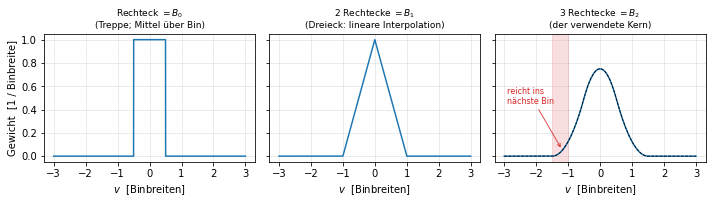

In [4]:
# Beispiel und Probe: B2 durch zweimaliges Falten eines Rechtecks,
# verglichen mit der geschlossenen Form (2.2).
n_sub = 2000  # Stützstellen je Binbreite
v = np.arange(-3 * n_sub, 3 * n_sub + 1) / n_sub
box = np.where(np.abs(v) < 0.5, 1.0, 0.0)
hut = np.convolve(box, box, mode="same") / n_sub
b2_gefaltet = np.convolve(hut, box, mode="same") / n_sub


def b2_geschlossen(v):
    v = np.abs(v)
    return np.where(
        v <= 0.5,
        0.75 - v**2,
        np.where(v <= 1.5, 0.5 * (1.5 - v) ** 2, 0.0),
    )


print(
    "Probe: max |B2 (gefaltet) - B2 (2.2)| =",
    np.max(np.abs(b2_gefaltet - b2_geschlossen(v))),
    "(Diskretisierung der numerischen Faltung)",
)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.9), sharey=True)
titel = [
    "Rechteck $= B_0$\n(Treppe; Mittel über Bin)",
    "2 Rechtecke $= B_1$\n(Dreieck: lineare Interpolation)",
    "3 Rechtecke $= B_2$\n(der verwendete Kern)",
]
for ax, y, t in zip(axes, [box, hut, b2_gefaltet], titel):
    ax.plot(v, y)
    ax.set_xlabel(r"$v$  [Binbreiten]")
    ax.set_title(t, fontsize=9)
axes[0].set_ylabel("Gewicht  [1 / Binbreite]")
axes[2].plot(v, b2_geschlossen(v), "k--", lw=0.8)
axes[2].axvspan(-1.5, -1.0, color="C3", alpha=0.15)
axes[2].annotate(
    "reicht ins\nnächste Bin",
    xy=(-1.2, 0.06),
    xytext=(-2.9, 0.45),
    fontsize=8,
    color="C3",
    arrowprops={"arrowstyle": "->", "color": "C3", "lw": 0.8},
)
plt.tight_layout()
plt.show()

## 3. Warum drei Rechtecke: Aliasing

Eine Faltung auf dem Bin-Gitter wendet nicht $Z$ an, sondern ein durch die
Abtastung zurückgefaltetes Spektrum (Poissonsche Summenformel). Mit $k$
Rechteck-Mittelungen auf der Wake und
$\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$ (Fourier-Transformierte des
Rechtecks, NumPy-Konvention) gilt

$$Z_\mathrm{eff}(f)
\;=\; \Delta t \sum_{n} \overline W(n\Delta t)\, e^{-2\pi i f n \Delta t}
\;=\;
\sum_{\ell=-\infty}^{\infty} Z\!\left(f + \tfrac{\ell}{\Delta t}\right)
\operatorname{sinc}^{k}\!\left(f\Delta t + \ell\right) , \tag{3.1}$$

also $\widetilde V(f) = Z_\mathrm{eff}(f)\,\tilde q(f)$ mit
$\tilde q(f) = \sum_j q_j e^{-2\pi i f t_j}$ (Probe in Abschnitt 7). Der Term
$\ell = 0$ ist die gewünschte Impedanz; jeder Term $\ell \ne 0$ ist ein
Alias-Anteil und wird mit $|\ell|^{-k}$ unterdrückt. Unterhalb der
Nyquist-Frequenz ist $\operatorname{sinc}^k$ reell und positiv: Die
Mittelung dämpft Amplituden, verschiebt aber nichts in der Zeit.

Wahl von $k$:

| $k$ | Modell | Alias-Anteile | Ergebnis (Verlustfaktor, Beispiel unten) |
|---|---|---|---|
| 0 | Punktwerte | ungedämpft | der bekannte Fehler bei kleinem $Q$ |
| 1 | ein Rechteck | $\propto\lvert\ell\rvert^{-1}$, Vorzeichen wechselt | unzuverlässig, teils Energie*gewinn* |
| 2 | Treppe + Mittel über Bin | $\propto\lvert\ell\rvert^{-2}$, alle $\ge 0$ | immer zu groß, bis Faktor 14 |
| 3 | Dreieck + Mittel über Bin | $\propto\lvert\ell\rvert^{-3}$, Vorzeichen wechselt | auf wenige Prozent genau |
| 4 | $B_3$ (verworfen) | $\propto\lvert\ell\rvert^{-4}$, alle $\ge 0$ | keine messbare Verbesserung |

($k = n + 1$ für $B_n$; das Modell benutzt $k = 3$, also $B_2$.)

**Bemerkung (Vorzeichen).** Wegen
$\sin(\pi(x+\ell)) = (-1)^\ell \sin(\pi x)$ ist

$$\operatorname{sinc}^k(f\Delta t + \ell) \;=\; (-1)^{k\ell}\,
\frac{\sin^k(\pi f\Delta t)}{\bigl(\pi(f\Delta t + \ell)\bigr)^{k}} .$$

Bei geradem $k$ sind alle Alias-Gewichte $\ge 0$: Mit
$\operatorname{Re}Z \ge 0$ (passive Impedanz) können die Alias-Anteile nur
Verlust *hinzufügen*. Bei ungeradem $k$ wechselt das Vorzeichen mit $\ell$.
Daher der negative Verlustfaktor bei $k = 1$; bei $k = 3$ heben sich
benachbarte Alias-Anteile teilweise auf.

Dass $k = 3$ und $k = 4$ in der Tabelle unten fast gleich abschneiden,
heißt *nicht*, dass kein Alias-Fehler mehr bleibt — zwei Effekte gleichen
sich aus. Die Zerlegung Band + Alias bei 2.4 Bins/$\sigma$ (Gewichtung (b))
ergibt $0.968 + 0.010$ für $k = 3$ und $0.958 + 0.020$ für $k = 4$. Die
Dämpfung im Band senkt den Verlust, der Alias-Anteil hebt ihn wieder. $k = 4$
hat sogar mehr Alias, weil sich seine Anteile nicht gegenseitig aufheben.

**Achtung.** $k = 2$ ist die *exakte* Spannung eines treppenförmigen
Strahls, aber ein schlechtes Modell für einen glatten Strahl: Der langsam
abfallende $|\ell|^{-2}$-Anteil verschiebt den resistiven Teil einer
Resonanz oberhalb von Nyquist in einen Frequenzbereich, in dem die wahre
Impedanz fast rein reaktiv ist. Eine reaktive Impedanz nimmt keine Energie
auf — der zusätzliche Verlust ist also erfunden, und der **Verlustfaktor**
zeigt ihn deutlich. Der Preis von $k = 3$ im Band ist
$\operatorname{sinc}^3(f\Delta t) = 1 - \tfrac12(\pi f\Delta t)^2 +
\mathcal O\big((f\Delta t)^4\big)$: ein Fehler zweiter Ordnung in
$\Delta t$, der beim Verfeinern verschwindet. Aliasing verschwände nicht.

Beispielparameter (wie im Docstring von `Resonators._wake_bin_average`):
Gauß-Bunch $\sigma = 12$ ns, Breitbandresonator $f_r = 1$ GHz, $Q = 0.907$,
$R_s = 1\,\Omega$; grobe Binnung 2.4 Bins/$\sigma$ ($\Delta t = 5$ ns,
Nyquist bei $f_r/10$).

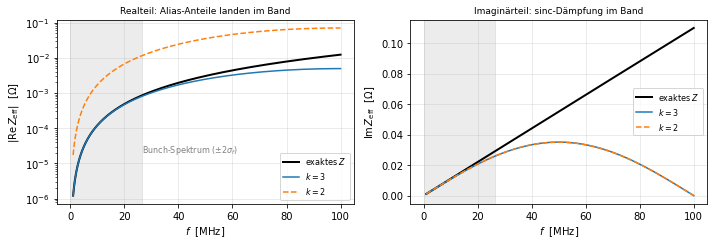

In [5]:
# Beispiel: die rückgefaltete Impedanz (3.1) des Breitbandresonators.
R_bb, f_r, Q_bb = 1.0, 1.0e9, 0.907
omega_r = 2 * np.pi * f_r
alpha_bb = omega_r / (2 * Q_bb)
omega_bar_bb = np.sqrt(omega_r**2 - alpha_bb**2)
pole_bb = -alpha_bb + 1j * omega_bar_bb
rho_bb = R_bb * alpha_bb * (1 + 1j * alpha_bb / omega_bar_bb)


def impedance(f, pole, rho):
    s = 2j * np.pi * f
    return rho / (s - pole) + np.conj(rho) / (s - np.conj(pole))


def z_effective(f, dt, k, pole, rho, ell_max=400):
    total = np.zeros(np.shape(f), dtype=complex)
    for ell in range(-ell_max, ell_max + 1):  # Alias-Anteile
        total += (
            impedance(f + ell / dt, pole, rho) * np.sinc(f * dt + ell) ** k
        )
    return total


sigma = 12e-9
dt_grob = sigma / 2.4  # 5 ns; Nyquist = 100 MHz = f_r / 10
sigma_f = 1 / (2 * np.pi * sigma)
f_band = np.linspace(1e6, 0.5 / dt_grob, 600)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
z_wahr = impedance(f_band, pole_bb, rho_bb)
z2 = z_effective(f_band, dt_grob, 2, pole_bb, rho_bb)
z3 = z_effective(f_band, dt_grob, 3, pole_bb, rho_bb)
axes[0].semilogy(
    f_band / 1e6, np.abs(z_wahr.real), "k", lw=2, label="exaktes $Z$"
)
axes[0].semilogy(f_band / 1e6, np.abs(z3.real), "C0-", label="$k = 3$")
axes[0].semilogy(f_band / 1e6, np.abs(z2.real), "C1--", label="$k = 2$")
axes[0].set_ylabel(r"$|\mathrm{Re}\,Z_\mathrm{eff}|$  [$\Omega$]")
axes[0].set_title("Realteil: Alias-Anteile landen im Band", fontsize=9)
axes[1].plot(f_band / 1e6, z_wahr.imag, "k", lw=2, label="exaktes $Z$")
axes[1].plot(f_band / 1e6, z3.imag, "C0-", label="$k = 3$")
axes[1].plot(f_band / 1e6, z2.imag, "C1--", label="$k = 2$")
axes[1].set_ylabel(r"$\mathrm{Im}\,Z_\mathrm{eff}$  [$\Omega$]")
axes[1].set_title("Imaginärteil: sinc-Dämpfung im Band", fontsize=9)
for ax in axes:
    ax.axvspan(0, 2 * sigma_f / 1e6, color="grey", alpha=0.15)
    ax.set_xlabel("$f$  [MHz]")
    ax.legend(fontsize=8)
axes[0].annotate(
    r"Bunch-Spektrum ($\pm 2\sigma_f$)",
    xy=(2 * sigma_f / 1e6, 2e-5),
    fontsize=8,
    color="grey",
)
plt.tight_layout()
plt.show()

In [6]:
# Beispiel: Verlustfaktor des diskreten Modells, normiert auf das
# Kontinuum (k_V ~ Integral Re Z |lambda~|^2 df), in zwei Gewichtungen:
# (a) mit dem sinc der Daten (die q_j sind Bin-Integrale,
#     Abschnitt 2) -- die aus dem Histogramm übertragene Energie;
# (b) ohne ihn -- nur die Qualität des Kerns, wie in der Tabelle
#     im Docstring von Resonators._wake_bin_average.
f_voll = np.linspace(0.1e6, 3000e6, 300000)
bunch_leistung = np.exp(-((2 * np.pi * f_voll * sigma) ** 2))
k_verlust_wahr = np.trapezoid(
    impedance(f_voll, pole_bb, rho_bb).real * bunch_leistung, f_voll
)

print("Verlustfaktor, diskretes Modell / Kontinuum\n")
for name, mit_histogramm_sinc in [
    ("(a) Gewicht |lambda~ sinc|^2  (Modell aus Histogrammdaten)", True),
    ("(b) Gewicht |lambda~|^2       (Kern isoliert; Docstring)", False),
]:
    print(name)
    print("Bins/sigma" + "".join(f"      k={k}" for k in (1, 2, 3, 4)))
    for bins_pro_sigma in (2.4, 7.2, 24.0):
        dt_ = sigma / bins_pro_sigma
        f_ = np.linspace(0.01e6, 0.5 / dt_, 4000)
        gewicht = np.exp(-0.5 * (2 * np.pi * f_ * sigma) ** 2)
        if mit_histogramm_sinc:
            gewicht = gewicht * np.sinc(f_ * dt_)
        gewicht = gewicht**2
        zeile = []
        for k in (1, 2, 3, 4):
            re_zeff = z_effective(f_, dt_, k, pole_bb, rho_bb).real
            zeile.append(np.trapezoid(re_zeff * gewicht, f_) / k_verlust_wahr)
        print(
            f"{bins_pro_sigma:10.1f}" + "".join(f" {r:+8.3f}" for r in zeile)
        )
    print()

# Probe (Zerlegung Band/Alias, Gewichtung (b)): k = 3 und k = 4
# ergeben fast dieselbe Summe, weil sich zwei Effekte ausgleichen --
# k = 4 dämpft das Band stärker UND hat mehr Alias (alle Anteile
# positiv); bei k = 3 heben sich die Anteile teilweise auf.
print("Zerlegung, Gewichtung (b):  Band (l=0) + Alias (l!=0) = gesamt")
for bins_pro_sigma in (2.4, 7.2):
    dt_ = sigma / bins_pro_sigma
    f_ = np.linspace(0.01e6, 0.5 / dt_, 4000)
    gewicht = np.exp(-((2 * np.pi * f_ * sigma) ** 2))
    for k in (2, 3, 4):
        band = (
            np.trapezoid(
                (impedance(f_, pole_bb, rho_bb) * np.sinc(f_ * dt_) ** k).real
                * gewicht,
                f_,
            )
            / k_verlust_wahr
        )
        gesamt = (
            np.trapezoid(
                z_effective(f_, dt_, k, pole_bb, rho_bb).real * gewicht, f_
            )
            / k_verlust_wahr
        )
        print(
            f"  {bins_pro_sigma:4.1f} Bins/sigma, k={k}:"
            f"  {band:+7.3f}  {gesamt - band:+8.3f}  = {gesamt:+7.3f}"
        )

Verlustfaktor, diskretes Modell / Kontinuum

(a) Gewicht |lambda~ sinc|^2  (Modell aus Histogrammdaten)
Bins/sigma      k=1      k=2      k=3      k=4
       2.4   +0.046  +13.646   +0.958   +0.957
       7.2   -3.099   +4.715   +0.995   +0.995
      24.0   +1.435   +1.155   +1.000   +0.999

(b) Gewicht |lambda~|^2       (Kern isoliert; Docstring)
Bins/sigma      k=1      k=2      k=3      k=4
       2.4   +0.047  +13.939   +0.978   +0.978
       7.2   -3.106   +4.726   +0.997   +0.997
      24.0   +1.435   +1.155   +1.000   +1.000

Zerlegung, Gewichtung (b):  Band (l=0) + Alias (l!=0) = gesamt
   2.4 Bins/sigma, k=2:   +0.979   +12.961  = +13.939
   2.4 Bins/sigma, k=3:   +0.968    +0.010  =  +0.978
   2.4 Bins/sigma, k=4:   +0.958    +0.020  =  +0.978
   7.2 Bins/sigma, k=2:   +0.998    +3.729  =  +4.726
   7.2 Bins/sigma, k=3:   +0.996    +0.001  =  +0.997
   7.2 Bins/sigma, k=4:   +0.995    +0.002  =  +0.997


**Ablesen:** Ein Rechteck ist unzuverlässig (bei 7.2 Bins/$\sigma$ sogar
Energie*gewinn*). Zwei Rechtecke erfinden bis zu 14-fachen Verlust. Drei
Rechtecke sind schon bei 2.4 Bins/$\sigma$ auf wenige Prozent genau und ab
24 Bins/$\sigma$ auf drei Stellen. Ein viertes bringt nichts mehr. Also
$k = 3$, der Kern ist $\overline W = W * B_2$.

Tabelle (b) lässt den $\operatorname{sinc}$ der Daten weg, bewertet also nur
den Kern; sie entspricht den Zahlen im Docstring von
`Resonators._wake_bin_average` (0.978, 13.9, …). Tabelle (a) enthält diesen
$\operatorname{sinc}$ und misst die Energie, die das Modell aus dem
Histogramm tatsächlich überträgt. Die Schlussfolgerung ist dieselbe.

## 4. Die gemittelte Wake in geschlossener Form

Einmal mit dem Rechteck mitteln heißt: Differenz der Stammfunktion,
$(g * \mathrm{Rechteck})(\tau) = \big[G(\tau + \tfrac{\Delta t}{2}) -
G(\tau - \tfrac{\Delta t}{2})\big]/\Delta t$ mit $G' = g$. Dreimal
angewandt ist $\overline W$ die **dritte Differenz einer dritten
Stammfunktion** $A_3$ (mit $A_3''' = W$):

$$\overline W(\tau) = \frac{
      A_3\!\left(\tau + \tfrac32\Delta t\right)
- 3\, A_3\!\left(\tau + \tfrac12\Delta t\right)
+ 3\, A_3\!\left(\tau - \tfrac12\Delta t\right)
-     A_3\!\left(\tau - \tfrac32\Delta t\right)}{\Delta t^3} . \tag{4.1}$$

Die dritte Differenz entfernt jedes Polynom bis Grad zwei, die
Integrationskonstanten spielen also keine Rolle. $A_3$ muss aber auf der
**ganzen** Achse eine dritte Stammfunktion sein, also auch über den Sprung
bei $\tau = 0$ hinweg zweimal stetig differenzierbar. Pro Pol ist das

$$\varphi_3(\tau) = \begin{cases}
\dfrac{e^{p\tau} - 1 - p\tau - \tfrac12 (p\tau)^2}{p^{3}}, & \tau > 0,\\[6pt]
0, & \tau \le 0,
\end{cases}
\qquad A_3 = 2\operatorname{Re}[\rho\,\varphi_3] \tag{4.2}$$

(das abgezogene Polynom sorgt für
$\varphi_3 = \varphi_3' = \varphi_3'' = 0$ bei $\tau = 0$). Für
$\tau > \tfrac32\Delta t$ sind alle vier Argumente positiv, das Polynom
fällt heraus, und es bleibt

$$\overline W(\tau)\Big|_{\tau > \frac32\Delta t}
= 2\operatorname{Re}\!\left[\rho
\left(\frac{e^{p\Delta t} - 1}{p\Delta t}\right)^{\!3}
e^{\,p\left(\tau - \frac32\Delta t\right)}\right] . \tag{4.3}$$

Anschaulich: Liegt das Mittelungsfenster
$(\tau - \tfrac32\Delta t,\ \tau + \tfrac32\Delta t)$ ganz hinter dem
Sprung, sieht es nur eine Exponentialfunktion — und deren Mittelwert ist
dieselbe Exponentialfunktion mal eine Konstante. Nur wenn das Fenster den
Sprung enthält ($|\tau| < \tfrac32\Delta t$), kommt etwas anderes heraus.
Für $\tau \le -\tfrac32\Delta t$ ist $\overline W = 0$.

> **Rezept 2 — $\overline W(\tau)$ auswerten**
>
> 1. $\tau \le -\tfrac32\Delta t$: $\overline W = 0$.
> 2. $\tau > \tfrac32\Delta t$ (Fernbereich): Formel (4.3).
> 3. Sonst (Nahbereich): $\varphi_3$ an den vier Stellen
>    $\tau \pm \tfrac12\Delta t$, $\tau \pm \tfrac32\Delta t$ auswerten
>    ($\varphi_3(x \le 0) = 0$), in (4.1) einsetzen, mal
>    $2\operatorname{Re}[\rho\,\cdot]$.
>    Für $|p\,x| < 1$ statt (4.2) die Reihe
>    $\varphi_3 = x^3 \sum_n (p x)^n/(n+3)!$ benutzen, sonst gehen Stellen
>    verloren.
> 4. Reeller Pol: Faktor 1 statt 2.

**Achtung.** (4.1) und (4.3) sind mathematisch gleich, numerisch aber
nicht: In (4.1) wachsen die Polynomterme wie $(p\tau)^2$ und heben sich erst
in der Differenz auf — der Rundungsfehler wächst quadratisch mit $\tau$.
(4.3) hat dieses Problem nicht, und für gedämpfte Pole ist jeder Faktor
höchstens eins ($\left|\frac{e^{z}-1}{z}\right| = \left|\int_0^1
e^{zu}\mathrm du\right| \le 1$ für $\operatorname{Re} z \le 0$). Deshalb
(4.1) **nur** nahe am Sprung und (4.3) überall sonst — so macht es
`triple_box_average_pole`. Beides wird unten gemessen.

In [7]:
# Probe zu (4.1)-(4.3), symbolisch, in Einheiten dt = 1.
p_s = sp.symbols("p", nonzero=True)  # Pol, in 1/Bin
x = sp.symbols("x", positive=True)
tau_s, v_s = sp.symbols("tau v", real=True)

phi3_s = (sp.exp(p_s * x) - 1 - p_s * x - (p_s * x) ** 2 / 2) / p_s**3
print(
    "Probe: phi3''' - e^(p x) =",
    sp.simplify(sp.diff(phi3_s, x, 3) - sp.exp(p_s * x)),
)
print(
    "Probe: phi3, phi3', phi3'' bei 0+ =",
    sp.limit(phi3_s, x, 0),
    sp.limit(sp.diff(phi3_s, x), x, 0),
    sp.limit(sp.diff(phi3_s, x, 2), x, 0),
)

# B2 stückweise (Träger (-3/2, 3/2)):
b2_stuecke = [
    (
        (sp.Rational(3, 2) + v_s) ** 2 / 2,
        sp.Rational(-3, 2),
        sp.Rational(-1, 2),
    ),
    (sp.Rational(3, 4) - v_s**2, sp.Rational(-1, 2), sp.Rational(1, 2)),
    ((sp.Rational(3, 2) - v_s) ** 2 / 2, sp.Rational(1, 2), sp.Rational(3, 2)),
]


def phi3_kausal(arg):
    return phi3_s.subs(x, arg) if arg > 0 else sp.Integer(0)


def dritte_differenz(t):
    t = sp.Rational(t)
    return (
        phi3_kausal(t + sp.Rational(3, 2))
        - 3 * phi3_kausal(t + sp.Rational(1, 2))
        + 3 * phi3_kausal(t - sp.Rational(1, 2))
        - phi3_kausal(t - sp.Rational(3, 2))
    )


def fenster_integral(t):
    # Integral von B2(v) e^{p (t - v)} über den kausalen Fensterteil
    t = sp.Rational(t)
    total = sp.Integer(0)
    for poly, lo, hi in b2_stuecke:
        hi = sp.Min(hi, t)
        if hi <= lo:
            continue
        total += sp.integrate(
            poly * sp.exp(p_s * (t - v_s)), (v_s, lo, hi), conds="none"
        )
    return total


for t in (-1, 0, 1):
    print(
        f"Probe: Fensterintegral - (4.1) bei tau = {t:+d} =",
        sp.simplify(sp.expand(fenster_integral(t) - dritte_differenz(t))),
    )

# Fernbereich: volles Fenster gegen (4.3), generisches tau ...
fern_formel = ((sp.exp(p_s) - 1) / p_s) ** 3 * sp.exp(
    p_s * (tau_s - sp.Rational(3, 2))
)
volles_fenster = sum(
    sp.integrate(
        poly * sp.exp(p_s * (tau_s - v_s)), (v_s, lo, hi), conds="none"
    )
    for poly, lo, hi in b2_stuecke
)
print(
    "Probe: volles Fensterintegral - (4.3) =",
    sp.simplify(sp.expand(volles_fenster - fern_formel)),
)

# ... und die Polynom-Auslöschung: dritte Differenz der ANALYTISCHEN
# phi3 (ohne kausalen Abschnitt) ist identisch (4.3).
dritte_diff_analytisch = (
    phi3_s.subs(x, tau_s + sp.Rational(3, 2))
    - 3 * phi3_s.subs(x, tau_s + sp.Rational(1, 2))
    + 3 * phi3_s.subs(x, tau_s - sp.Rational(1, 2))
    - phi3_s.subs(x, tau_s - sp.Rational(3, 2))
)
print(
    "Probe: dritte Differenz (analytisch) - (4.3) =",
    sp.simplify(sp.expand(dritte_diff_analytisch - fern_formel)),
)

Probe: phi3''' - e^(p x) = 0
Probe: phi3, phi3', phi3'' bei 0+ = 0 0 0
Probe: Fensterintegral - (4.1) bei tau = -1 = 0
Probe: Fensterintegral - (4.1) bei tau = +0 = 0
Probe: Fensterintegral - (4.1) bei tau = +1 = 0
Probe: volles Fensterintegral - (4.3) = 0
Probe: dritte Differenz (analytisch) - (4.3) = 0


In [8]:
# Beispiel und Probe zu Rezept 2: gegen brute-force-Integration
# von B2(v) W(tau - v dt) und gegen die BLonD-Implementierung.
def phi3(tau, pole):
    tau = np.asarray(tau, dtype=float)
    out = np.zeros(tau.shape, dtype=complex)
    kausal = tau > 0
    z = pole * tau[kausal]
    out[kausal] = (np.exp(z) - 1 - z - z**2 / 2) / pole**3
    return out


def wbar_via_phi3(tau, pole, rho, dt):
    # Rezept 2, Schritt 3 -- Form (4.1): überall gültig, aber
    # ungenau bei großem |p tau|
    dritte_diff = (
        phi3(tau + 1.5 * dt, pole)
        - 3 * phi3(tau + 0.5 * dt, pole)
        + 3 * phi3(tau - 0.5 * dt, pole)
        - phi3(tau - 1.5 * dt, pole)
    )
    return 2 * np.real(rho * dritte_diff) / dt**3


def wbar_fern(tau, pole, rho, dt):
    # Rezept 2, Schritt 2 -- Form (4.3): nur für tau > 1.5 dt, jeder
    # Faktor höchstens eins
    z = pole * dt
    return 2 * np.real(
        rho
        * (np.expm1(z) / z) ** 3
        * np.exp(pole * (np.asarray(tau, dtype=float) - 1.5 * dt))
    )


def wbar(tau, pole, rho, dt):
    # Rezept 2 komplett, wie BLonDs triple_box_average_pole: (4.1)
    # nahe am Sprung, (4.3) dahinter; die Argumente werden je Zweig
    # begrenzt, damit der nicht benutzte Zweig kein inf/NaN erzeugt
    tau = np.asarray(tau, dtype=float)
    onset = 1.5 * dt
    fern = tau > onset
    tau_fern = np.where(fern, tau, onset)
    tau_nah = np.where(fern, onset, tau)
    return np.where(
        fern,
        wbar_fern(tau_fern, pole, rho, dt),
        wbar_via_phi3(tau_nah, pole, rho, dt),
    )


def b2_skalar(v):
    av = abs(v)
    if av <= 0.5:
        return 0.75 - v * v
    if av <= 1.5:
        return 0.5 * (1.5 - av) ** 2
    return 0.0


def wbar_bruteforce(tau, pole, rho, dt):
    def integrand(v):
        arg = tau - v * dt
        if arg <= 0:
            return 0.0
        return b2_skalar(v) * 2 * np.real(rho * np.exp(pole * arg))

    sprungstelle = min(max(tau / dt, -1.5), 1.5)
    pts = sorted({-1.5, -0.5, 0.5, 1.5, sprungstelle})
    return quad(integrand, -1.5, 1.5, points=pts, limit=200)[0]


import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    from blond.physics.impedances.bin_average import (
        triple_box_average_pole,
    )

print("Abstand m   brute force      Rezept 2         BLonD")
lags = np.array([-2.0, -1.4, -1.0, -0.5, 0.0, 0.5, 1.0, 1.4, 2.0, 3.0, 5.5])
schlechtester = 0.0
for m in lags:
    t_ = m * dt_demo
    brute = wbar_bruteforce(t_, pole_demo, rho_demo, dt_demo)
    rezept = float(wbar(np.array([t_]), pole_demo, rho_demo, dt_demo)[0])
    ref = float(
        triple_box_average_pole(np.array([t_]), pole_demo, rho_demo, dt_demo)[
            0
        ]
    )
    schlechtester = max(schlechtester, abs(brute - rezept), abs(ref - rezept))
    print(f"{m:+9.1f}   {brute:+.6e}   {rezept:+.6e}   {ref:+.6e}")
print(
    "Probe: schlechteste Abweichung =",
    schlechtester,
    f"(Kern-Skala {2 * abs(rho_demo):.2e})",
)

# »Achtung« aus Abschnitt 4, gemessen: der Fehler von (4.1) wächst
# wie Abstand^2, das Rezept bleibt auf Rundungsniveau
print("\nFehler von (4.1) gegen Rezept 2, wachsender Abstand:")
for m in (2, 8, 32, 128, 512):
    a = float(
        wbar_via_phi3(np.array([m * dt_demo]), pole_demo, rho_demo, dt_demo)[0]
    )
    b = float(wbar(np.array([m * dt_demo]), pole_demo, rho_demo, dt_demo)[0])
    print(f"  Abstand {m:4d} Bins:  |Differenz| = {abs(a - b):.2e}")

Abstand m   brute force      Rezept 2         BLonD
     -2.0   +0.000000e+00   +0.000000e+00   +0.000000e+00
     -1.4   +6.534588e+04   +6.534588e+04   +6.534588e+04
     -1.0   +6.245701e+06   +6.245701e+06   +6.245701e+06
     -0.5   +2.377546e+07   +2.377546e+07   +2.377546e+07
     +0.0   +1.109149e+07   +1.109149e+07   +1.109149e+07
     +0.5   -3.251405e+07   -3.251405e+07   -3.251405e+07
     +1.0   -1.666324e+07   -1.666324e+07   -1.666324e+07
     +1.4   +1.395241e+07   +1.395241e+07   +1.395241e+07
     +2.0   -8.055328e+06   -8.055328e+06   -8.055328e+06
     +3.0   +1.071705e+07   +1.071705e+07   +1.071705e+07
     +5.5   +1.994246e+06   +1.994246e+06   +1.994246e+06
Probe: schlechteste Abweichung = 6.05359673500061e-08 (Kern-Skala 4.00e+08)

Fehler von (4.1) gegen Rezept 2, wachsender Abstand:
  Abstand    2 Bins:  |Differenz| = 1.58e-08
  Abstand    8 Bins:  |Differenz| = 9.41e-08
  Abstand   32 Bins:  |Differenz| = 8.98e-07
  Abstand  128 Bins:  |Differenz| = 1.45e-05


## 5. Das Fernfeld: eine Rekursion mit zwei Bins Verzögerung

Die Summe (2.1), aufgeteilt nach dem Abstand $m = i - j$. Ab $m = 2$ gilt
die Fernform (4.3); die drei kleinsten Abstände behandelt Abschnitt 6:

$$V_i \;=\;
\underbrace{\sum_{j \le i-2} q_j\, \overline W\big((i-j)\Delta t\big)}
_{\text{Fernfeld: geometrische Folge}}
\;+\;
\underbrace{q_{i-1}\,\overline W(\Delta t) + q_i\,\overline W(0)
          + q_{i+1}\,\overline W(-\Delta t)}
_{\text{Nahfeld: drei Nachbarbins}} . \tag{5.1}$$

Direkt ausgewertet kostet die Fernfeld-Summe $\mathcal O(N)$ pro Bin, also
$\mathcal O(N^2)$ pro Umlauf. Gesucht ist eine Rechenvorschrift, die
*dieselben Zahlen* mit festem Aufwand pro Bin liefert. In drei Schritten:

**1. Einsetzen.** Für $m \ge 2$ ist $\tau = m\Delta t > \tfrac32\Delta t$,
(4.3) gilt also exakt. Mit
$\tau - \tfrac32\Delta t = (m-2)\,\Delta t + \tfrac12\Delta t$ wird

$$\overline W(m\Delta t)
= 2\operatorname{Re}\!\Bigg[
\underbrace{\rho\left(\frac{e^{p\Delta t}-1}{p\Delta t}\right)^{\!3}
e^{\,p\Delta t/2}}_{=:\ \rho_\mathrm{rec}}\;
\underbrace{\big(e^{p\Delta t}\big)^{m-2}}_{=:\ z^{\,m-2}}
\Bigg] .$$

Mit jedem Bin Abstand kommt ein Faktor $z$ hinzu.

**2. Summe hineinziehen.** Die $q_j$ sind reell, also

$$V_i^{\mathrm{fern}}
= \sum_{j \le i-2} q_j\, 2\operatorname{Re}\!\big[\rho_\mathrm{rec}\,
z^{\,i-2-j}\big]
= 2\operatorname{Re}\!\Bigg[\rho_\mathrm{rec}
\underbrace{\sum_{j \le i-2} q_j\, z^{\,i-2-j}}_{=:\ S_i}\Bigg] .$$

Die Abhängigkeit von $i$ steckt nur noch in der komplexen Zahl $S_i$: der
Summe aller Ladungen bis Bin $i-2$, jede mit
$z^{\,i-2-j} = e^{\,p(t_i - 2\Delta t - t_j)}$ gedämpft und in der Phase
gedreht — wie der Phasor der Strahlbelastung einer Kavität.

**3. Neuesten Term abspalten.** Den Term $j = i-2$ herausnehmen und aus dem
Rest ein $z$ ausklammern:

$$S_i
= q_{i-2} + \sum_{j \le i-3} q_j\, z^{\,i-2-j}
= q_{i-2} + z \sum_{j \le i-3} q_j\, z^{\,(i-1)-2-j}
= z\, S_{i-1} + q_{i-2} ,$$

mit $S_i = 0$, solange noch keine Ladung zwei Bins zurückliegt. Diese
Rekursion — mit $z$ multiplizieren, $q_{i-2}$ addieren,
$V_i^{\mathrm{fern}} = 2\operatorname{Re}[\rho_\mathrm{rec}\,S_i]$ ablesen —
ergibt Term für Term dieselbe Summe. Es wird nichts genähert. Aufwand: eine
Multiplikation und eine Addition pro Bin und Pol.

> **Rezept 3 — induzierte Spannung, Nahfeld + Fernfeld**
>
> *Vorbereitung (einmal pro Pol):*
> 1. $p$ und $\rho$ nach Rezept 1 (oder Vector Fit).
> 2. $z = e^{p\Delta t}$ und
>    $\rho_\mathrm{rec} = \rho\left(\frac{e^{p\Delta t}-1}{p\Delta t}
>    \right)^{3} e^{p\Delta t/2}$.
> 3. Die drei Nahfeld-Gewichte nach Rezept 2:
>    $w_- = \overline W(\Delta t)$ (voriges Bin),
>    $w_0 = \overline W(0)$ (eigenes Bin),
>    $w_+ = \overline W(-\Delta t)$ (nächstes Bin).
> 4. $S = 0$.
>
> *Für jedes Bin $i = 0, 1, 2, \dots$:*
>
> 5. Dämpfen: $S \leftarrow z\,S$ (für $i > 0$).
> 6. Ladung addieren: $S \leftarrow S + q_{i-2}$ (für $i \ge 2$).
> 7. Fernfeld: $V_i = 2\operatorname{Re}[\rho_\mathrm{rec}\, S]$.
> 8. Nahfeld: $V_i \mathrel{+}= q_{i-1} w_- + q_i w_0 + q_{i+1} w_+$
>    (am Rand fehlende Nachbarn weglassen).
>
> Aufwand $\mathcal O(1)$ pro Bin und Pol; am Ende über alle Pole
> summieren.

**Bemerkung.**
(i) *Warum zwei Bins Verzögerung?* Man könnte $S$ auch auf $t_i$ statt auf
$t_i - 2\Delta t$ beziehen. Dann steckt in der Konstante beim Ablesen aber
ein Faktor $e^{-2p\Delta t}$, der bei starker Dämpfung riesig wird: Je nach
Auswertung läuft er ab $\alpha\Delta t \approx 355$ bis $486$ über, während
$S$ ab $\alpha\Delta t \approx 373$ auf null abrundet. Ergebnis:
$\infty$, $\infty \cdot 0 = \mathrm{NaN}$ oder eine stille Null (Probe:
Extremfall am Ende von Abschnitt 6). Mit zwei Bins Verzögerung ist jeder
Faktor — $z$, die addierte Ladung und $\rho_\mathrm{rec}/\rho$ — höchstens
eins. Nichts kann überlaufen, bei keiner Binnung.
(ii) Der BLonD-Kernel (`wake_from_pole_residue`, `STATE_LAG_BINS = 2`)
kann in Schritt 5 auch mehrere Bins auf einmal dämpfen,
$e^{p\,(\mathrm{step}\cdot\Delta t)}$. So überspringt er leere Bins und
rechnet über die Umlaufgrenze hinweg mit derselben Summe $S$. Die
Verzögerung ist eine *Zeit* ($2\Delta t$), kein Array-Index.
(iii) Den Faktor 2 für den konjugierten Pol wendet der Kernel beim Addieren
der Ladung an statt beim Ablesen (gleiches Ergebnis); ein reeller Pol wird
ohne Faktor 2 addiert.

In [9]:
# Probe zu den drei Schritten: die Rekursion ergibt Term für Term
# die explizite Summe S_i = sum_{j <= i-2} q_j z^(i-2-j).
rng = np.random.default_rng(3)
q_probe = rng.random(40)
z_step = np.exp(pole_demo * dt_demo)
zustand = 0j
schlechtester = 0.0
for i in range(40):
    if i > 0:
        zustand *= z_step  # Dämpfen
    if i >= 2:
        zustand += q_probe[i - 2]  # Ladung addieren
    summe = sum(
        q_probe[j] * z_step ** (i - 2 - j) for j in range(max(0, i - 1))
    )
    schlechtester = max(schlechtester, abs(zustand - summe))
print("Probe: max |Rekursion - explizite Summe| =", schlechtester)

Probe: max |Rekursion - explizite Summe| = 3.1401849173675503e-16


## 6. Das Nahfeld: was die Rekursion nicht kann

Die Rekursion liefert ab $m = 2$ Werte der Form $c\,z^m$, also eine
geometrische Folge. Mehr kann eine Rekursion mit nur einer Zahl $S$ nicht
(bis auf höchstens einen direkten Term, siehe Bemerkung (ii)). Der exakte
Kern weicht davon bei genau drei Abständen ab, $m \in \{-1, 0, 1\}$: Dort
enthält das Mittelungsfenster den Sprung bei $\tau = 0$ (Abschnitt 4). Diese
drei Werte **müssen** getrennt berechnet werden — das ist der Nahfeld-Term in
(5.1) bzw. Schritt 8 von Rezept 3. Im Code (`MultiPoleSparseSolve`):
`_lag_prev_factors`, `_lag_zero_factor`, `_lag_next_factors`, einmal
berechnet in `_setup_near_field_kernel`, pro Umlauf angewandt in
`_add_near_field_voltage`.

**Bemerkung** (zwei naheliegende Abkürzungen, die nicht funktionieren):
(i) *Die Ladung statt der Wake glätten* — etwa mit festen Gewichten
$\tfrac18, \tfrac34, \tfrac18$ — und dann die ungemittelte Wake in die
Rekursion geben: Das ergibt nicht $\overline W$, denn der Faktor
$\bigl(\frac{e^{p\Delta t}-1}{p\Delta t}\bigr)^3$ hängt vom Pol ab. Feste
Gewichte versagen, sobald $|p\Delta t| \gtrsim 1$ — genau der Fall, um den
es hier geht.
(ii) *Geschickter diskretisieren* (exakte Lösung der
Differentialgleichung, First-Order-Hold, anders gewichtetes Addieren): Das
ergibt wieder $c\,z^m$ plus höchstens **einen** zusätzlichen direkten Term.
Gebraucht werden aber drei freie Werte.

Das Bild zeigt den exakten Kern, seine geometrische Fortsetzung (4.3) —
alles, was die Rekursion darstellen kann — und die drei Nahfeld-Werte, die
davon abweichen.

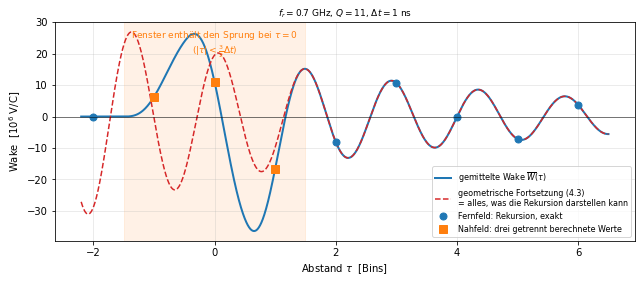

   m    exakter Kern     geometrisch (4.3)  auf der Kurve?
  -1   +6.245701e+06   -3.007820e+05    False
  +0   +1.109149e+07   +1.953116e+07    False
  +1   -1.666324e+07   -9.820159e+06    False
  +2   -8.055328e+06   -8.055328e+06    True
  +3   +1.071705e+07   +1.071705e+07    True
  +4   -9.860538e+04   -9.860538e+04    True
  +5   -7.134414e+06   -7.134414e+06    True
  +6   +3.726911e+06   +3.726911e+06    True


In [10]:
# Beispiel: der gemittelte Kern, seine geometrische Fortsetzung
# und die drei Nahfeld-Werte, die die Rekursion nicht darstellen
# kann. (Die ungemittelte Wake ist hier ~12x größer -- ein schlecht
# aufgelöster Pol wird stark weggemittelt -- und liegt außerhalb
# des Bildes.)
tau_fein = np.linspace(-2.2, 6.5, 3000) * dt_demo
kern_fein = wbar(tau_fein, pole_demo, rho_demo, dt_demo)
geometrisch_fein = wbar_fern(tau_fein, pole_demo, rho_demo, dt_demo)

m_gitter = np.arange(-2, 7)
kern_taps = wbar(m_gitter * dt_demo, pole_demo, rho_demo, dt_demo)
nah = (m_gitter >= -1) & (m_gitter <= 1)

skala = 1e6
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    tau_fein / dt_demo,
    kern_fein / skala,
    "C0",
    lw=2,
    label=r"gemittelte Wake $\overline{W}(\tau)$",
)
ax.plot(
    tau_fein / dt_demo,
    geometrisch_fein / skala,
    "C3--",
    lw=1.5,
    label="geometrische Fortsetzung (4.3)\n"
    "= alles, was die Rekursion darstellen kann",
)
ax.plot(
    m_gitter[~nah],
    kern_taps[~nah] / skala,
    "C0o",
    ms=7,
    label="Fernfeld: Rekursion, exakt",
)
ax.plot(
    m_gitter[nah],
    kern_taps[nah] / skala,
    "C1s",
    ms=8,
    label="Nahfeld: drei getrennt berechnete Werte",
)
ax.axvspan(-1.5, 1.5, color="C1", alpha=0.10)
ax.text(
    0,
    0.97,
    "Fenster enthält den Sprung bei $\\tau = 0$\n"
    r"($|\tau| < \frac{3}{2}\Delta t$)",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=9,
    color="C1",
)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel(r"Abstand $\tau$  [Bins]")
ax.set_ylabel(r"Wake  [$10^{6}$ V/C]")
ax.set_title(
    rf"$f_r = {f_r_demo / 1e9:.1f}$ GHz, $Q = {Q_demo:.0f}$,"
    rf" $\Delta t = {dt_demo * 1e9:.0f}$ ns",
    fontsize=9,
)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# Tabelle erst ab m = -1: für m <= -2 sind Kern und Rekursion
# beide null -- dort gibt es nichts zu korrigieren.
print("   m    exakter Kern     geometrisch (4.3)  auf der Kurve?")
ab_minus_eins = m_gitter >= -1
for m, k_wert in zip(m_gitter[ab_minus_eins], kern_taps[ab_minus_eins]):
    geo = float(
        wbar_fern(np.array([m * dt_demo]), pole_demo, rho_demo, dt_demo)[0]
    )
    gleich = abs(k_wert - geo) < 1e-9 * 2 * abs(rho_demo)
    print(f"{m:+4d}   {k_wert:+.6e}   {geo:+.6e}    {gleich}")

In [11]:
# Beispiel zu Rezept 3 und Probe: die Aufteilung ist exakt, keine
# Näherung -- Vergleich mit der direkten Faltung mit dem exakten
# Kern.
def nahfeld_fernfeld_spannung(q, pole, rho, dt):
    # Referenz für die Rechnung pro Pol in MultiPoleSparseSolve;
    # Schritte wie in Rezept 3
    n = len(q)
    z_dt = pole * dt
    # Schritt 2
    zerfall = np.exp(z_dt)
    rho_rec = rho * (np.expm1(z_dt) / z_dt) ** 3 * np.exp(z_dt / 2)
    # Schritt 3
    w_minus, w_null, w_plus = wbar(np.array([dt, 0.0, -dt]), pole, rho, dt)
    # Schritt 4
    zustand = 0j
    spannung = np.zeros(n)
    for i in range(n):
        if i > 0:
            zustand *= zerfall  # Schritt 5: Dämpfen
        if i >= 2:
            zustand += q[i - 2]  # Schritt 6: Ladung addieren
        spannung[i] = 2 * np.real(rho_rec * zustand)  # Schritt 7
        spannung[i] += q[i] * w_null  # Schritt 8
        if i >= 1:
            spannung[i] += q[i - 1] * w_minus
        if i + 1 < n:
            spannung[i] += q[i + 1] * w_plus
    return spannung


rng = np.random.default_rng(7)
q_zufall = rng.random(64)
lag_achse = np.arange(-63, 64)
kern_alle = wbar(lag_achse * dt_demo, pole_demo, rho_demo, dt_demo)
v_direkt = np.array(
    [
        sum(q_zufall[j] * kern_alle[(i - j) + 63] for j in range(64))
        for i in range(64)
    ]
)
v_split = nahfeld_fernfeld_spannung(q_zufall, pole_demo, rho_demo, dt_demo)
print(
    "Probe: max |Aufteilung - direkte Faltung| / max |V| =",
    np.max(np.abs(v_split - v_direkt)) / np.max(np.abs(v_direkt)),
)

# Probe (Extremfall, Abschnitt 5, Bemerkung (i)): sehr starke
# Dämpfung, alpha*dt = 400 -- z.B. ein stark gedämpfter reeller
# Vector-Fit-Pol auf grobem Gitter. Mit 2 Bins Verzögerung bleibt
# jeder Faktor endlich. Auf t_i bezogen läuft der getrennte Faktor
# exp(-2 p dt) über, und S rundet auf null ab: Ergebnis NaN. In
# einem Exponenten zusammengefasst bleibt die Konstante hier
# endlich (Überlauf erst ab ~473).
pol_extrem = -400.0 / dt_demo  # reeller Pol, Residuum 1
z_dt_x = pol_extrem * dt_demo
with np.errstate(over="ignore", under="ignore", invalid="ignore"):
    rho_rec_x = (np.expm1(z_dt_x) / z_dt_x) ** 3 * np.exp(z_dt_x / 2)
    print(
        "mit 2 Bins Verzögerung:  |z| =",
        abs(np.exp(z_dt_x)),
        "  |rho_rec| =",
        abs(rho_rec_x),
    )
    ablese_konstante = rho_rec_x * np.exp(-2 * z_dt_x)
    zustand_ohne_lag = np.exp(2 * z_dt_x) * 1.0  # addiert wird z^2 q, q=1
    print(
        "ohne Verzögerung: |Konstante| =",
        abs(ablese_konstante),
        "  Ergebnis =",
        ablese_konstante * zustand_ohne_lag,
    )
    # in EINEM Exponenten zusammengefasst: bei alpha*dt = 400 noch
    # endlich, das Ergebnis ist still 0 statt ~1e-95 (harmlos)
    konst_gefaltet = (np.expm1(z_dt_x) / z_dt_x) ** 3 * np.exp(-1.5 * z_dt_x)
    print(
        "ohne Verzögerung, ein Exponent: |Konstante| =",
        abs(konst_gefaltet),
        "  Ergebnis =",
        konst_gefaltet * zustand_ohne_lag,
    )

Probe: max |Aufteilung - direkte Faltung| / max |V| = 1.2941110009886479e-15
mit 2 Bins Verzögerung:  |z| = 1.9151695967140057e-174   |rho_rec| = 2.162338323026153e-95
ohne Verzögerung: |Konstante| = inf   Ergebnis = nan
ohne Verzögerung, ein Exponent: |Konstante| = 5.895344220203032e+252   Ergebnis = 0.0


## 7. Restfehler

Die Aufteilung in Nah- und Fernfeld ist exakt (Probe oben:
Maschinengenauigkeit). Der gesamte Modellfehler kommt davon, dass auf
Histogrammdaten $W$ durch $\overline W = W * B_2$ ersetzt wird:

* **Dämpfung im Band:** Gegenüber $\widetilde V = Z\tilde\lambda$ enthält
  das Modell den Faktor $\operatorname{sinc}^4(f\Delta t)$ — drei aus
  $B_2$, einen aus den Daten (die $q_j$ sind Bin-Integrale, Abschnitt 2,
  Bemerkung (ii)). $1 - \operatorname{sinc}^4 \approx
  \tfrac23 (\pi f\Delta t)^2$: zweite Ordnung in $\Delta t$, rein reell,
  ohne Phasen- oder Zeitverschiebung.
* **Alias-Rest** $\propto |\ell|^{-3}$: laut Zerlegung in Abschnitt 3 bei
  $k = 3$ nur $+0.010$ des Verlustfaktors (2.4 Bins/$\sigma$) bzw.
  $+0.001$ (7.2 Bins/$\sigma$).
* **Im Zeitbereich:** lineare Interpolation zwischen den Binmitten, Fehler
  $\mathcal O(\Delta t^2 \lambda'')$; unten gemessen: Ordnung 2.
* **Profilrand:** Dem letzten Bin fehlt der Beitrag des nächsten Bins, weil
  es keinen gibt — ein Effekt an genau diesem einen Bin. Die Wirkung der
  letzten Bins auf den nächsten Aufruf rechnet der Solver dagegen mit dem
  tatsächlichen, meist nicht ganzzahligen Abstand nach
  (`_carry_previous_call`, `_trailing_tap`).
* **Rundung:** siehe »Achtung« in Abschnitt 4; die Rekursion selbst ist
  stabil (alle Faktoren $\le 1$).

**Achtung** (Referenzrechnung): Schon das glatte Integral numerisch zu
berechnen ist heikel. Eine Riemann-Summe
$\sum_m W(\tau_m)\lambda(t - \tau_m)\,\delta\tau$ behandelt den Sprung bei
$\tau = 0$ nur dann richtig, wenn der Punkt bei $\tau = 0$ den **halben**
Sprung bekommt (wie in Abschnitt 1). Weil die Impedanz im Band fast reaktiv
ist, heben sich die Beiträge stark auf; ein falscher Wert an dieser einen
Stelle verfälscht das Ergebnis darum grob — um einen Faktor zwei bis zu
Größenordnungen, bis zum falschen Vorzeichen. Die Referenz unten wird
deshalb im Frequenzraum berechnet, $\widetilde V = Z\tilde\lambda$ mit dem
analytischen Gauß-Spektrum. Dasselbe Problem hat `ImpedanceTableTime`: Dort
muss man angeben, wie der erste Tabellenwert gemeint ist
(`first_sample_is_half_jump`).

Probe: Modell gegen Vorhersage (3.1) = 4.1920768214020104e-13
Restfehler gegen glatte Referenz     = 0.009025958712648326


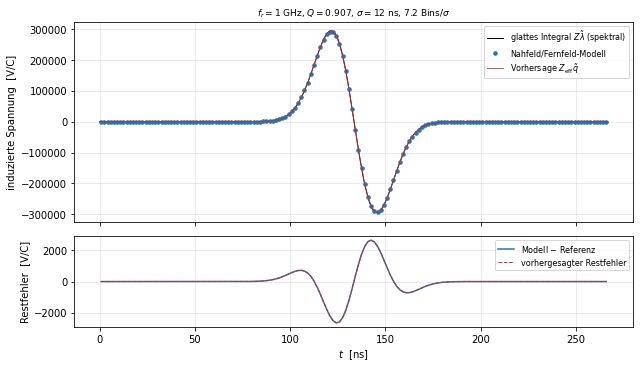

In [12]:
# Beispiel: glatte Referenz gegen das Nahfeld/Fernfeld-Modell,
# Breitbandresonator (Abschnitt 3), 7.2 Bins pro sigma. Obendrauf die
# Vorhersage (3.1): das Modell liegt bis auf 1e-13 darauf -- der
# Restfehler ist ein bekannter Filter, kein Rauschen.
bins_pro_sigma = 7.2
dt_e = sigma / bins_pro_sigma
n_bins = 160
mitte = n_bins * dt_e / 2
bin_mitten = (np.arange(n_bins) + 0.5) * dt_e

# Binladungen eines Gauß mit Ladung eins, exakt per Fehlerfunktion
kanten = np.arange(n_bins + 1) * dt_e
cdf = 0.5 * (1 + erf((kanten - mitte) / (sigma * np.sqrt(2))))
q_bins = np.diff(cdf)

# das Nahfeld/Fernfeld-Modell (Rezept 3)
v_modell = nahfeld_fernfeld_spannung(q_bins, pole_bb, rho_bb, dt_e)

# glatte Referenz, spektral: V~ = Z lambda~ mit analytischem
# Gauß-Spektrum, invertiert auf einem 400x feineren Gitter (die
# Riemann-Summe im Zeitbereich bräuchte den halben Sprung bei
# tau = 0, siehe »Achtung« oben)
oversample = 400
dt_fein = dt_e / oversample
n_fft_fein = 1 << 18  # 1.1 us periodisches Fenster; 1/alpha = 0.3 ns
f_fein = np.fft.rfftfreq(n_fft_fein, d=dt_fein)
lambda_spektrum = np.exp(-0.5 * (2 * np.pi * f_fein * sigma) ** 2) * np.exp(
    -2j * np.pi * f_fein * mitte
)
v_referenz_fein = (
    np.fft.irfft(impedance(f_fein, pole_bb, rho_bb) * lambda_spektrum)
    / dt_fein
)
t_gitter = np.arange(n_fft_fein) * dt_fein
# die Binmitten liegen exakt auf dem feinen Gitter
v_referenz = v_referenz_fein[np.arange(n_bins) * oversample + oversample // 2]

# die Vorhersage (3.1): V~ = Z_eff q~, invertiert auf dem Bin-Gitter
n_fft = 8192
q_gepolstert = np.zeros(n_fft)
q_gepolstert[:n_bins] = q_bins
f_fft = np.fft.rfftfreq(n_fft, d=dt_e)
z_eff_3 = z_effective(f_fft, dt_e, 3, pole_bb, rho_bb, ell_max=300)
# Z_eff ist die *skalierte* DTFT (Faktor dt in (3.1)); beim
# Invertieren wieder herausteilen
v_vorhersage = (
    np.fft.irfft(np.fft.rfft(q_gepolstert) * z_eff_3, n=n_fft)[:n_bins] / dt_e
)

print(
    "Probe: Modell gegen Vorhersage (3.1) =",
    np.max(np.abs(v_modell - v_vorhersage)) / np.max(np.abs(v_modell)),
)
print(
    "Restfehler gegen glatte Referenz     =",
    np.max(np.abs(v_modell - v_referenz)) / np.max(np.abs(v_referenz)),
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 5.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]},
)
t_ns = bin_mitten * 1e9
n_zeig = n_bins * oversample
axes[0].plot(
    t_gitter[:n_zeig] * 1e9,
    v_referenz_fein[:n_zeig],
    "k",
    lw=1,
    label=r"glattes Integral $Z\tilde\lambda$ (spektral)",
)
axes[0].plot(t_ns, v_modell, "C0o", ms=3.5, label="Nahfeld/Fernfeld-Modell")
axes[0].plot(
    t_ns,
    v_vorhersage,
    "C3-",
    lw=0.8,
    label=r"Vorhersage $Z_\mathrm{eff}\,\tilde q$",
)
axes[0].set_ylabel("induzierte Spannung  [V/C]")
axes[0].legend(fontsize=8)
axes[0].set_title(
    rf"$f_r = 1$ GHz, $Q = 0.907$, $\sigma = 12$ ns,"
    rf" {bins_pro_sigma} Bins/$\sigma$",
    fontsize=9,
)
axes[1].plot(
    t_ns, v_modell - v_referenz, "C0", lw=1.5, label="Modell $-$ Referenz"
)
axes[1].plot(
    t_ns,
    v_vorhersage - v_referenz,
    "C3--",
    lw=1,
    label="vorhergesagter Restfehler",
)
axes[1].set_xlabel("$t$  [ns]")
axes[1].set_ylabel("Restfehler  [V/C]")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Bins/sigma: [ 6. 12. 24. 48.]
relativer Maximalfehler: [0.00663157 0.00165974 0.0004159  0.00010425]
Probe: paarweise Konvergenzordnung = [2. 2. 2.]


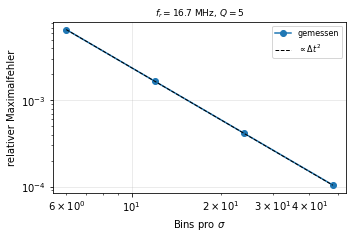

In [13]:
# Probe: Konvergenzordnung an einem AUFGELÖSTEN Resonator (f_r
# unterhalb Nyquist bei jeder Binnung): der Restfehler fällt wie dt^2.
f_r_tief, Q_tief = 0.2 / sigma, 5.0  # 16.7 MHz, Q = 5
omega_tief = 2 * np.pi * f_r_tief
alpha_tief = omega_tief / (2 * Q_tief)
omega_bar_tief = np.sqrt(omega_tief**2 - alpha_tief**2)
pole_tief = -alpha_tief + 1j * omega_bar_tief
rho_tief = alpha_tief * (1 + 1j * alpha_tief / omega_bar_tief)

binnungen = np.array([6.0, 12.0, 24.0, 48.0])
fehler = []
for bins_pro_sigma_ in binnungen:
    dt_ = sigma / bins_pro_sigma_
    n_ = int(2 * round(10 * sigma / dt_ / 2))
    mitte_ = n_ * dt_ / 2
    kanten_ = np.arange(n_ + 1) * dt_
    cdf_ = 0.5 * (1 + erf((kanten_ - mitte_) / (sigma * np.sqrt(2))))
    q_ = np.diff(cdf_)
    v_modell_ = nahfeld_fernfeld_spannung(q_, pole_tief, rho_tief, dt_)

    # spektrale Referenz wie oben; das periodische Fenster ist so
    # gepolstert, dass das ~95-ns-Abklingen vor dem Umlauf stirbt
    over_ = 200
    dt_f = dt_ / over_
    n_fft_ = 1 << int(np.ceil(np.log2((n_ * dt_ + 1.5e-6) / dt_f)))
    f_f = np.fft.rfftfreq(n_fft_, d=dt_f)
    lam_spektrum_ = np.exp(-0.5 * (2 * np.pi * f_f * sigma) ** 2) * np.exp(
        -2j * np.pi * f_f * mitte_
    )
    v_ref_f = (
        np.fft.irfft(impedance(f_f, pole_tief, rho_tief) * lam_spektrum_)
        / dt_f
    )
    v_ref_ = v_ref_f[np.arange(n_) * over_ + over_ // 2]

    fehler.append(np.max(np.abs(v_modell_ - v_ref_)) / np.max(np.abs(v_ref_)))

fehler = np.array(fehler)
ordnungen = -np.diff(np.log(fehler)) / np.diff(np.log(binnungen))
print("Bins/sigma:", binnungen)
print("relativer Maximalfehler:", fehler)
print("Probe: paarweise Konvergenzordnung =", np.round(ordnungen, 2))

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.loglog(binnungen, fehler, "C0o-", label="gemessen")
ax.loglog(
    binnungen,
    fehler[0] * (binnungen / binnungen[0]) ** -2.0,
    "k--",
    lw=1,
    label=r"$\propto \Delta t^{2}$",
)
ax.set_xlabel(r"Bins pro $\sigma$")
ax.set_ylabel("relativer Maximalfehler")
ax.set_title(
    rf"$f_r = {f_r_tief / 1e6:.1f}$ MHz, $Q = {Q_tief:.0f}$", fontsize=9
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Übersicht: Formel $\leftrightarrow$ BLonD-Code

| hier | Code |
|---|---|
| $p$, $\rho$ des Resonators (Rezept 1) | `Resonators.get_vectorfit`, `Resonators._wake_bin_average` — `blond/physics/impedances/sources.py` |
| $B_2$ (2.2) | `quadratic_bspline` — `blond/physics/impedances/bin_average.py` |
| $\varphi_3$ (4.2), Reihe für $\lvert p\tau\rvert < 1$ | `causal_third_antiderivative_factor` — ebd. |
| Fernform (4.3) | `_smoothed_pole` — ebd. |
| Rezept 2 komplett | `triple_box_average_pole(s)` — ebd.; als `Resonators.get_wake_per_bin` exportiert |
| $Z_\mathrm{eff}$ (3.1), Verlustfaktoren | Docstrings von `bin_average.py` und `Resonators._wake_bin_average` (dort ohne den $\operatorname{sinc}$ der Daten, wie Tabelle (b) in Abschnitt 3) |
| Rekursion (Rezept 3, Schritte 5–7) | `Specials.wake_from_pole_residue`, eine Implementierung je Backend; `STATE_LAG_BINS` — `blond/core/backends/backend.py` |
| $\rho_\mathrm{rec}$, Startwert von $S$ (Schritte 2, 4) | `MultiPoleSparseSolve._setup_far_field_recursion` — `blond/physics/impedances/solvers.py` |
| die drei Nahfeld-Gewichte (Schritte 3, 8) | `MultiPoleSparseSolve._setup_near_field_kernel`, `_add_near_field_voltage` |
| Übergang zwischen Aufrufen, nicht ganzzahliger Abstand | `MultiPoleSparseSolve._carry_previous_call`, `_trailing_tap`, `_inject_off_grid_carry` |

Nicht behandelt, weil es nur Buchführung derselben Mathematik ist: Profile
mit leeren Bereichen, der Übergang zwischen zwei Aufrufen bei nicht
ganzzahligem Bin-Abstand, gegenläufige Strahlen. Die Summe $S$ ist auf eine
*Zeit* bezogen; alles Weitere sind Dämpfungsintervalle und die Zeitpunkte,
zu denen Ladung addiert wird (Details in den Docstrings von `solvers.py`).

Die übrigen Zeitbereichs-Solver (`SingleTurnResonatorConvolutionSolver`,
`MultiPassResonatorSolver`, `ContinuousMultiTurnTimeDomainSolver`) falten
mit demselben $\overline W$ (`get_wake_per_bin`); `TimeDomainFftSolver`
multipliziert im Frequenzraum mit dessen Fourier-Transformierter
(`get_impedance_from_wake`). Deshalb stimmen sie auch bei schlecht
aufgelösten Resonatoren überein. `PeriodicFreqSolver` wertet für
`Resonators` dagegen das analytische $Z$ nur unterhalb von Nyquist aus:
kein Aliasing, aber auch keine $\operatorname{sinc}^3$-Dämpfung. Er weicht
von den anderen daher um $\mathcal O\big((f\Delta t)^2\big)$ ab.

*Herleitungen, ausführliche Fehleranalyse und englische Fassung:*
`explain_nearfield_farfield_model.ipynb`.